# NLP, Token, Embedding, Transformer และ Prompt Engineering

**Phase 3: Deep Learning และ Generative AI**


วันนี้เราจะผ่า "เครื่องยนต์" ที่อยู่เบื้องหลัง ChatGPT/Claude ให้เห็นข้างใน แล้วลงมือสร้างของจริง

สิ่งที่จะได้วันนี้
--------------------------------------------------------------------------------
- เข้าใจว่าคอมพิวเตอร์เปลี่ยน "ตัวอักษร" เป็น "ตัวเลข" ได้อย่างไร (Token)
- เข้าใจ Embedding = "แผนที่ความหมาย" ที่ทำให้ AI รู้ว่าคำไหนความหมายใกล้กัน
- เข้าใจ Transformer และ Attention หัวใจเบื้องหลัง AI ยุคใหม่ แบบเห็นภาพ
- สร้าง AI ค้นหาคำตอบจากคู่มือด้วย "ความหมาย" (semantic search) ของจริง
- รัน LLM ตัวจริงบนเครื่อง แล้วฝึก Prompt Engineering แบบอัปเดตปี 2026

### ขั้นตอนแรก: ติดตั้งไลบรารีและ Font ภาษาไทยสำหรับ Matplotlib

วันนี้มีของใหม่ 4 ตัว ติดตั้งครั้งเดียวจบ:
- `tiktoken` ตัวตัด token แบบเดียวกับที่ GPT ใช้
- `pythainlp` เครื่องมือ NLP ภาษาไทย (ตัดคำไทย)
- `sentence-transformers` แปลงประโยคเป็นเวกเตอร์ (Embedding)
- `transformers` ไว้รัน LLM ตัวจริง

In [1]:
# ติดตั้งไลบรารี (รันครั้งเดียว ใช้เวลาสักครู่)
!pip install -q tiktoken pythainlp sentence-transformers transformers accelerate gensim

# ติดตั้ง font Sarabun (ภาษาไทย) สำหรับ matplotlib
!wget -q https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf -O Sarabun-Regular.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont("Sarabun-Regular.ttf")
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Sarabun"
plt.rcParams["axes.unicode_minus"] = False
print("ติดตั้งเรียบร้อย พร้อมใช้ฟอนต์ภาษาไทยบนกราฟแล้ว")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.7 MB/s eta 0:00:00
ติดตั้งเรียบร้อย พร้อมใช้ฟอนต์ภาษาไทยบนกราฟแล้ว


### Imports และการตั้งค่าพื้นฐาน
เราตั้ง seed = 42 เหมือนทุกสัปดาห์ เพื่อให้ผลรันออกมาเหมือนเดิมทุกครั้ง และเลือกใช้ GPU ถ้ามี

In [2]:
%matplotlib inline
# ========== Imports ==========
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# เพื่อให้ผลลัพธ์เหมือนเดิมทุกครั้ง (เหมือน Week 9-10)
np.random.seed(42)
torch.manual_seed(42)

# ใช้ GPU ถ้ามี (บน Colab: Runtime > Change runtime type > T4 GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("อุปกรณ์ที่ใช้:", device)
if device == "cpu":
    print("หมายเหตุ: ส่วนรัน LLM (ช่วงที่ 7) ต้องการ GPU โปรดเปิด T4 GPU ก่อนถึงช่วงนั้น")

อุปกรณ์ที่ใช้: cuda


---

## ช่วงที่ 1: ทบทวน + เปิดปริศนา


**ปริศนาวันนี้:** ถ้าเรามี **ข้อความ** เช่น "เครื่องจักรเสีย" เราจะเอา CNN มาอ่านข้อความตรง ๆ ได้ไหม?

คำตอบคือ **ไม่ได้** ด้วย 3 เหตุผล:
1. ภาพเป็นตัวเลขอยู่แล้ว แต่ **ข้อความเป็นตัวอักษร** ไม่ใช่ตัวเลข
2. ภาพมีขนาดคงที่ แต่ **ข้อความยาวไม่เท่ากัน** (ประโยคสั้นบ้างยาวบ้าง)
3. **ความหมายขึ้นกับลำดับและบริบท** เช่น "หมากัดคน" กับ "คนกัดหมา" คำเหมือนกันแต่ความหมายต่างกัน

เราจึงต้องมีเครื่องมือใหม่ 3 ชิ้น: **Token แปลงคำเป็นตัวเลข, Embedding ใส่ความหมาย, Attention อ่านบริบท**

### 1.1 แผนการเรียนวันนี้ — 5 ก้าว
1. **ช่วงที่ 2 — Token:** หั่นข้อความเป็นชิ้นเล็ก ๆ แล้วแปลงเป็นตัวเลข (รวมความท้าทายของภาษาไทย)
2. **ช่วงที่ 3 — Embedding:** เปลี่ยนคำให้เป็นเวกเตอร์บน "แผนที่ความหมาย"
3. **ช่วงที่ 4 — Transformer และ Attention:** หัวใจเบื้องหลัง ChatGPT แบบเห็นภาพ
4. **ช่วงที่ 5-6 — Workshop และ Mini Project:** สร้าง AI ค้นคำตอบจากคู่มือด้วยความหมาย
5. **ช่วงที่ 7 — Prompt Engineering:** รัน LLM ตัวจริง แล้วฝึกสั่งงานให้ได้ผลดี (อัปเดตปี 2026)

---

## ช่วงที่ 2: Token — หั่นข้อความให้โมเดลรู้จัก

ความจริงที่หลายคนไม่รู้: โมเดลภาษา (เช่น GPT) **ไม่ได้เห็นตัวอักษร** ที่เราพิมพ์ มันเห็นแต่ **ตัวเลข**

ขั้นตอนแรกสุดของทุกระบบ AI ภาษา คือเปลี่ยนข้อความเป็นตัวเลข เรียกว่า **Tokenization**

### 2.1 Analogy — Token คือ "ชิ้นต่อ" ของข้อความ

ลองนึกถึงการต่อเลโก้ แทนที่จะมองข้อความเป็นตัวอักษรทีละตัว หรือเป็นคำเต็มทั้งคำ โมเดลยุคนี้หั่นข้อความเป็น **"ชิ้นย่อย" (subword)** ขนาดกลาง ๆ:
- คำที่พบบ่อย (เช่น the, hello) เก็บไว้ทั้งคำ เป็น 1 ชิ้น
- คำที่หายาก ถูกหั่นเป็นชิ้นที่คุ้นเคย เช่น "tokenization" หั่นเป็น "token" + "ization"

วิธีนี้เรียกว่า **BPE (Byte-Pair Encoding)** แต่ละชิ้นจะถูกแทนด้วย **เลขประจำตัว (token ID)** มาดูของจริงที่ GPT-4o ใช้กัน

In [3]:
# ========== Tokenizer ของ GPT-4o (o200k_base) ==========
import tiktoken
enc = tiktoken.get_encoding("o200k_base")  # ตัวเดียวกับที่ GPT-4o ใช้

examples = ["tokenization", "hello world", "unbelievable"]
for text in examples:
    ids = enc.encode(text)
    pieces = [enc.decode([i]) for i in ids]
    print(f"{text!r}")
    print(f"   หั่นได้ {len(ids)} ชิ้น: {pieces}")
    print(f"   เลขประจำตัว (token ID): {ids}")
    print()

'tokenization'
   หั่นได้ 2 ชิ้น: ['token', 'ization']
   เลขประจำตัว (token ID): [10346, 2860]

'hello world'
   หั่นได้ 2 ชิ้น: ['hello', ' world']
   เลขประจำตัว (token ID): [24912, 2375]

'unbelievable'
   หั่นได้ 3 ชิ้น: ['un', 'bel', 'ievable']
   เลขประจำตัว (token ID): [373, 9880, 45794]



### 2.2 ทำไม AI นับตัวอักษรผิด และคูณเลขพลาด (ความลับอยู่ที่ Token)

เคยสงสัยไหมว่าทำไมบางที AI ตอบเลขผิด หรือนับตัวอักษรผิด คำตอบไม่ใช่ "AI โง่" แต่เป็นเพราะ **การหั่น token** ลองดู 2 ตัวอย่างนี้

In [4]:
# ========== ความลับ 1: คำว่า strawberry ถูกหั่นจน 'r' กระจาย ==========
word = "strawberry"
ids = enc.encode(word)
pieces = [enc.decode([i]) for i in ids]
print(f"{word!r} ถูกหั่นเป็น: {pieces}")
print("ตัว r อยู่กระจายในชิ้น 'raw' และ 'berry' โมเดลเลยนับ r ได้ยาก")
print("(ไม่ใช่เพราะโมเดลโง่ แต่เพราะมันไม่เห็นตัวอักษร เห็นแต่ชิ้น token)")
print()

# ========== ความลับ 2: ตัวเลขหลายหลักถูกหั่นเป็นก้อนมั่ว ==========
print("ตัวเลขถูกหั่นแบบไม่มีความหมายเชิงเลข:")
for n in ["7", "42", "1000", "123456", "2026"]:
    ids = enc.encode(n)
    pieces = [enc.decode([i]) for i in ids]
    print(f"   {n!r:9} -> {pieces}")
print("เช่น 1000 ถูกหั่นเป็น '100' + '0' โมเดลเลยคูณเลขหลายหลักพลาดได้ง่าย")

'strawberry' ถูกหั่นเป็น: ['st', 'raw', 'berry']
ตัว r อยู่กระจายในชิ้น 'raw' และ 'berry' โมเดลเลยนับ r ได้ยาก
(ไม่ใช่เพราะโมเดลโง่ แต่เพราะมันไม่เห็นตัวอักษร เห็นแต่ชิ้น token)

ตัวเลขถูกหั่นแบบไม่มีความหมายเชิงเลข:
   '7'       -> ['7']
   '42'      -> ['42']
   '1000'    -> ['100', '0']
   '123456'  -> ['123', '456']
   '2026'    -> ['202', '6']
เช่น 1000 ถูกหั่นเป็น '100' + '0' โมเดลเลยคูณเลขหลายหลักพลาดได้ง่าย


### 2.3 ความท้าทายของภาษาไทย — ไม่มีเว้นวรรคระหว่างคำ

ภาษาอังกฤษมี "ช่องว่าง" บอกขอบเขตคำชัดเจน (I love programming = 3 คำ) แต่ **ภาษาไทยเขียนติดกันหมด** ไม่มีเว้นวรรค ทำให้การตัดคำยากกว่ามาก

นี่เป็นปัญหาที่นักวิจัยไทยพยายามแก้มานาน เราใช้ `PyThaiNLP` มาช่วยตัดคำได้

In [5]:
# ========== ตัดคำไทยด้วย PyThaiNLP ==========
from pythainlp.tokenize import word_tokenize

# อังกฤษ: ตัดด้วยช่องว่างง่าย ๆ
print("อังกฤษ (มีช่องว่าง):", "I love programming".split())
print()

# ไทย: ต้องใช้พจนานุกรมช่วยตัด (engine newmm)
thai_examples = ["เครื่องจักรเสีย", "สปินเดิลมีเสียงดังผิดปกติ", "ฉันรักการเขียนโปรแกรม"]
for t in thai_examples:
    toks = word_tokenize(t, engine="newmm")
    print(f"{t!r}")
    print(f"   ตัดได้: {toks}")
print()

# ความกำกวมของภาษาไทย: ตัดได้หลายแบบ
tricky = "ในประเทศไทย"
toks = word_tokenize(tricky, engine="newmm")
print(f"ตัวอย่างความกำกวม: {tricky!r}")
print(f"   เครื่องตัดได้: {toks}")
print("   แต่ความหมายจริงควรเป็น ['ใน', 'ประเทศไทย'] -- เห็นไหมว่าตัดคำไทยยากจริง")

อังกฤษ (มีช่องว่าง): ['I', 'love', 'programming']

'เครื่องจักรเสีย'
   ตัดได้: ['เครื่องจักร', 'เสีย']
'สปินเดิลมีเสียงดังผิดปกติ'
   ตัดได้: ['สปินเดิล', 'มี', 'เสียงดัง', 'ผิดปกติ']
'ฉันรักการเขียนโปรแกรม'
   ตัดได้: ['ฉัน', 'รัก', 'การเขียน', 'โปรแกรม']

ตัวอย่างความกำกวม: 'ในประเทศไทย'
   เครื่องตัดได้: ['ในประเทศ', 'ไทย']
   แต่ความหมายจริงควรเป็น ['ใน', 'ประเทศไทย'] -- เห็นไหมว่าตัดคำไทยยากจริง


### 2.4 สรุปช่วงที่ 2: Token กับเรื่องเงินและขีดจำกัด

นอกจากเรื่องเทคนิค Token ยังเกี่ยวกับ **ค่าใช้จ่ายจริง** ด้วย:
- บริการ AI (GPT, Claude, Gemini) **คิดเงินตามจำนวน token** ยิ่ง prompt ยาว ยิ่งจ่ายเยอะ
- แต่ละโมเดลมี **ขีดจำกัด context** (เช่น รับได้ 128,000 token) ไม่ใช่ 128,000 คำ
- ผู้ให้บริการแต่ละเจ้าตัด token ไม่เหมือนกัน ประโยคเดียวกันจึงได้จำนวน token และราคาต่างกัน

**ใจความช่วงนี้:** ข้อความ -> หั่นเป็น token -> แปลงเป็นเลขประจำตัว นี่คือประตูบานแรกที่ข้อความเข้าสู่โลกของ AI

---

## ช่วงที่ 3: Embedding — แผนที่ความหมาย

เราแปลงคำเป็นเลขประจำตัวแล้ว แต่เลขประจำตัวยัง **ไม่มีความหมาย** (token ID ของ "แมว" กับ "หมา" เป็นแค่เลขสุ่ม ๆ ไม่ได้บอกว่าทั้งคู่เป็นสัตว์)

**Embedding** คือก้าวต่อไป เปลี่ยนแต่ละคำให้เป็น **เวกเตอร์** (ชุดตัวเลขหลายค่า) ที่ **เก็บความหมาย** เอาไว้

### 3.1 Analogy — วางคำลงบน "แผนที่ความหมาย"

ลองนึกถึงแผนที่ประเทศไทย เมืองที่อยู่ใกล้กันบนแผนที่ มักเดินทางถึงกันง่าย

Embedding ทำแบบเดียวกันกับ "ความหมาย" คือวางทุกคำลงบนแผนที่ (ที่มีหลายมิติ) โดยที่:
- คำที่ความหมายใกล้กัน อยู่ใกล้กันบนแผนที่ (เช่น "เสีย" กับ "ชำรุด")
- คำที่ความหมายต่างกัน อยู่ไกลกัน (เช่น "เสีย" กับ "ลาพักร้อน")

เราวัดความใกล้ด้วยค่าที่เรียกว่า **cosine similarity** (0 = ไม่เกี่ยวกันเลย, 1 = เหมือนกันมาก) มาดูของจริง

In [6]:
# ========== แปลงประโยคเป็นเวกเตอร์ แล้ววัดความใกล้ ==========
from sentence_transformers import SentenceTransformer

# โมเดลรองรับหลายภาษารวมถึงไทย (โหลดครั้งแรกใช้เวลาสักครู่ ไม่ต้องล็อกอิน)
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("โหลดโมเดลเรียบร้อย ขนาดเวกเตอร์ =", embedder.get_sentence_embedding_dimension(), "มิติ")
print()

sentences = ["เครื่องจักรเสีย", "เครื่องจักรชำรุด", "พนักงานลาพักร้อน"]
emb = embedder.encode(sentences, normalize_embeddings=True)
sim = emb @ emb.T  # คูณกันได้ cosine similarity (เพราะ normalize แล้ว)

print("ตาราง cosine similarity (ยิ่งใกล้ 1 ยิ่งความหมายเหมือน):")
print(" " * 22, "  ".join(f"({i})" for i in range(len(sentences))))
for i, s in enumerate(sentences):
    row = "  ".join(f"{sim[i][j]:.2f}" for j in range(len(sentences)))
    print(f"({i}) {s:18} {row}")
print()
print(f"'เสีย' vs 'ชำรุด'      = {sim[0][1]:.2f}  (สูง เพราะความหมายเหมือนกัน แม้คนละคำ)")
print(f"'เสีย' vs 'ลาพักร้อน'  = {sim[0][2]:.2f}  (ต่ำ เพราะคนละเรื่อง)")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

โหลดโมเดลเรียบร้อย ขนาดเวกเตอร์ = 384 มิติ

ตาราง cosine similarity (ยิ่งใกล้ 1 ยิ่งความหมายเหมือน):
                       (0)  (1)  (2)
(0) เครื่องจักรเสีย    1.00  0.95  0.23
(1) เครื่องจักรชำรุด   0.95  1.00  0.23
(2) พนักงานลาพักร้อน   0.23  0.23  1.00

'เสีย' vs 'ชำรุด'      = 0.95  (สูง เพราะความหมายเหมือนกัน แม้คนละคำ)
'เสีย' vs 'ลาพักร้อน'  = 0.23  (ต่ำ เพราะคนละเรื่อง)


### 3.2 เห็นภาพ "แผนที่ความหมาย" จริง ๆ

เวกเตอร์มีหลายร้อยมิติ มองด้วยตาไม่ได้ เราจะ "ย่อ" ลงเหลือ 2 มิติเพื่อวาดบนกระดาษ (เชื่อม Week 6 เรื่องการลดมิติ) แล้วดูว่าคำที่ความหมายกลุ่มเดียวกันเกาะกันไหม

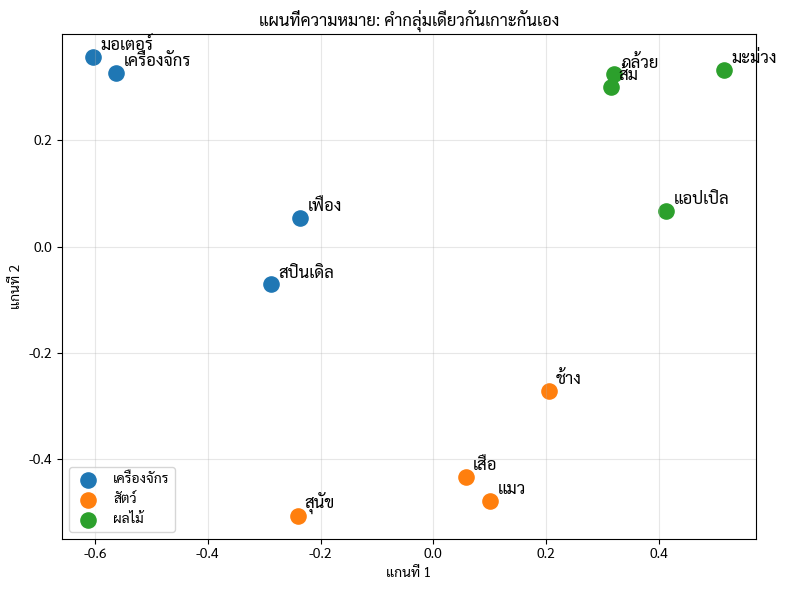

สังเกต: เครื่องจักร สัตว์ ผลไม้ แยกเป็น 3 กลุ่มชัดเจน ทั้งที่เราไม่เคยบอกโมเดลว่าอันไหนเป็นกลุ่มไหน


In [7]:
# ========== ย่อเวกเตอร์ลง 2 มิติ แล้ววาดแผนที่ความหมาย ==========
from sklearn.decomposition import PCA

words = [
    "เครื่องจักร", "มอเตอร์", "สปินเดิล", "เฟือง",      # กลุ่มเครื่องจักร
    "แมว", "สุนัข", "ช้าง", "เสือ",                     # กลุ่มสัตว์
    "ส้ม", "กล้วย", "มะม่วง", "แอปเปิล",                # กลุ่มผลไม้
]
groups = ["เครื่องจักร"]*4 + ["สัตว์"]*4 + ["ผลไม้"]*4
colors = {"เครื่องจักร": "tab:blue", "สัตว์": "tab:orange", "ผลไม้": "tab:green"}

vecs = embedder.encode(words, normalize_embeddings=True)
xy = PCA(n_components=2, random_state=42).fit_transform(vecs)

plt.figure(figsize=(8, 6))
for g in colors:
    idx = [i for i, gg in enumerate(groups) if gg == g]
    plt.scatter(xy[idx, 0], xy[idx, 1], c=colors[g], s=120, label=g)
for i, w in enumerate(words):
    plt.annotate(w, (xy[i, 0], xy[i, 1]), fontsize=12, xytext=(5, 5), textcoords="offset points")
plt.title("แผนที่ความหมาย: คำกลุ่มเดียวกันเกาะกันเอง")
plt.xlabel("แกนที่ 1"); plt.ylabel("แกนที่ 2")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("สังเกต: เครื่องจักร สัตว์ ผลไม้ แยกเป็น 3 กลุ่มชัดเจน ทั้งที่เราไม่เคยบอกโมเดลว่าอันไหนเป็นกลุ่มไหน")

### 3.3 เวกเตอร์เก็บความหมายดีจนทำ "คณิตศาสตร์กับความหมาย" ได้

นี่คือตัวอย่างคลาสสิกที่ทำให้คนทึ่ง เมื่อความหมายกลายเป็นเวกเตอร์ เราเอามา **บวกลบ** กันได้

`king - man + woman` ควรได้อะไร? ลองคิดตามตรรกะ: เอา "ราชา" ลบความเป็น "ผู้ชาย" แล้วเติมความเป็น "ผู้หญิง" น่าจะได้ "ราชินี" มาดูว่าเวกเตอร์คิดแบบเดียวกับเราไหม

In [8]:
# ========== คณิตศาสตร์กับความหมาย (ใช้ word vectors ภาษาอังกฤษ GloVe) ==========
try:
    import gensim.downloader as api
    print("กำลังโหลด word vectors (ครั้งแรกใช้เวลาสักครู่)...")
    wv = api.load("glove-wiki-gigaword-50")
    print("โหลดเสร็จ มีคำศัพท์", len(wv), "คำ")
    print()

    problems = [
        (["king", "woman"], ["man"],     "king - man + woman"),
        (["paris", "italy"], ["france"], "paris - france + italy"),
        (["walking", "swim"], ["walk"],  "walking - walk + swim"),
    ]
    for pos, neg, desc in problems:
        ans = wv.most_similar(positive=pos, negative=neg, topn=1)[0]
        print(f"{desc:28} = {ans[0]}   (ความมั่นใจ {ans[1]:.2f})")
    print()
    print("เวกเตอร์ตอบ: ราชา-ชาย+หญิง = ราชินี, ปารีส-ฝรั่งเศส+อิตาลี = โรม (เมืองหลวง!) -- มันเข้าใจความสัมพันธ์จริง")
except Exception as e:
    print("ข้ามตัวอย่าง word arithmetic เพราะโหลด GloVe ไม่สำเร็จ:", repr(e))
    print("ส่วนนี้เป็นโบนัส ไม่กระทบเนื้อหาหลักของบทเรียน")

กำลังโหลด word vectors (ครั้งแรกใช้เวลาสักครู่)...
[==================================================] 100.0% 66.0/66.0MB downloaded
โหลดเสร็จ มีคำศัพท์ 400000 คำ

king - man + woman           = queen   (ความมั่นใจ 0.85)
paris - france + italy       = rome   (ความมั่นใจ 0.85)
walking - walk + swim        = swimming   (ความมั่นใจ 0.81)

เวกเตอร์ตอบ: ราชา-ชาย+หญิง = ราชินี, ปารีส-ฝรั่งเศส+อิตาลี = โรม (เมืองหลวง!) -- มันเข้าใจความสัมพันธ์จริง


### 3.4 ปัญหาที่ Embedding ธรรมดายังแก้ไม่ได้ (ปูทางสู่ Attention)

Embedding ที่เราเห็นเป็นแบบ **"static"** คือคำหนึ่งคำได้เวกเตอร์เดียวเสมอ ไม่ว่าจะอยู่ในประโยคไหน

แต่ภาษาจริงไม่ง่ายขนาดนั้น ดูคำว่า **"เสีย"** ใน 3 ประโยค:
- "เครื่องจักร**เสีย**" (พัง)
- "เขา**เสีย**ใจมาก" (เศร้า)
- "ซ่อมแล้ว**เสีย**เงินเยอะ" (จ่าย)

คำเดียวกัน แต่ความหมายต่างกันสิ้นเชิง ขึ้นกับ **บริบท** รอบ ๆ คำ Embedding แบบ static ให้เวกเตอร์เดียวกันหมด เลยแยกไม่ออก

ใครจะมาช่วยอ่านบริบท? คำตอบคือพระเอกของช่วงต่อไป: **Attention**

---

## ช่วงที่ 4: Transformer และ Attention — หัวใจเบื้องหลัง ChatGPT

มาถึงพระเอกของวันนี้ **Attention** คือกลไกที่ทำให้โมเดลอ่าน "บริบท" ได้ และเป็นหัวใจของสถาปัตยกรรม **Transformer** ที่อยู่เบื้องหลัง ChatGPT, Claude, Gemini ทุกตัว

### 4.1 Analogy — Attention เหมือน "การค้นหาในห้องสมุด"

เวลาเราอ่านคำหนึ่งคำ สมองเราจะ "เหลือบมอง" คำอื่นรอบ ๆ เพื่อเข้าใจความหมาย เช่นอ่านคำว่า "เสีย" เราจะมองคำข้าง ๆ ว่าเป็น "เครื่องเสีย" หรือ "เสียใจ"

Attention ทำแบบเดียวกัน โดยใช้แนวคิดเหมือนการค้นห้องสมุด แต่ละคำมี 3 บทบาท:
- **Query (คำถาม):** "ฉันกำลังมองหาอะไร" -- สิ่งที่คำนี้อยากรู้จากคำอื่น
- **Key (ป้ายชื่อ):** "ฉันเกี่ยวกับเรื่องอะไร" -- ป้ายโฆษณาของแต่ละคำ
- **Value (เนื้อหา):** ข้อมูลจริงของคำนั้น

วิธีทำงาน: เอา Query ของคำเราไปเทียบกับ Key ของทุกคำ คำไหน Key ตรงกับ Query มาก ก็ให้ "ความสนใจ" (น้ำหนัก) กับ Value ของคำนั้นมาก แล้วรวมกันเป็นความหมายใหม่ที่รู้บริบทแล้ว

### 4.2 ทำมือ — Self-Attention เวอร์ชันจิ๋ว

มาดูกลไกจริงด้วยตัวเลขง่าย ๆ เราจะใช้ 4 คำ แต่ละคำมีเวกเตอร์ 4 มิติ (ตั้งค่าเองให้เห็นภาพ) โดยจงใจให้:
- "แมว" กับ "สัตว์" มีเวกเตอร์คล้ายกัน
- "วิ่ง" กับ "เร็ว" มีเวกเตอร์คล้ายกัน

แล้วดูว่า attention จับความสัมพันธ์นี้ได้ไหม (ขั้นตอน: เทียบความเข้ากัน -> softmax ให้รวมเป็น 1 -> รวมถ่วงน้ำหนัก)

In [9]:
# ========== Self-Attention ทำมือ ==========
torch.manual_seed(42)
wordlist = ["แมว", "วิ่ง", "เร็ว", "สัตว์"]
X = torch.tensor([
    [1.0, 0.0, 0.0, 0.9],   # แมว
    [0.0, 1.0, 0.8, 0.0],   # วิ่ง
    [0.0, 0.8, 1.0, 0.0],   # เร็ว
    [0.9, 0.0, 0.0, 1.0],   # สัตว์
])
d = X.shape[1]

# เวอร์ชันง่ายสุด: Query = Key = Value = X (ยังไม่มี matrix เรียนรู้)
scores = (X @ X.T) / (d ** 0.5)       # 1) เทียบความเข้ากันของทุกคู่คำ
attn   = F.softmax(scores, dim=1)     # 2) softmax: แต่ละแถวรวมได้ 1
output = attn @ X                     # 3) รวมถ่วงน้ำหนักของทุกคำ

print("น้ำหนัก attention (แต่ละคำ 'มอง' คำไหนมากแค่ไหน):")
for i, w in enumerate(wordlist):
    pairs = ", ".join(f"{wordlist[j]}={attn[i][j]:.2f}" for j in range(len(wordlist)))
    print(f"  {w:5} มอง -> {pairs}")
print()
print("สังเกต: 'แมว' มอง 'สัตว์' มากเป็นพิเศษ และ 'วิ่ง' มอง 'เร็ว' มากเป็นพิเศษ")
print("        attention จับคู่คำที่เกี่ยวข้องกันได้เอง")

น้ำหนัก attention (แต่ละคำ 'มอง' คำไหนมากแค่ไหน):
  แมว   มอง -> แมว=0.36, วิ่ง=0.14, เร็ว=0.14, สัตว์=0.35
  วิ่ง  มอง -> แมว=0.15, วิ่ง=0.35, เร็ว=0.34, สัตว์=0.15
  เร็ว  มอง -> แมว=0.15, วิ่ง=0.34, เร็ว=0.35, สัตว์=0.15
  สัตว์ มอง -> แมว=0.35, วิ่ง=0.14, เร็ว=0.14, สัตว์=0.36

สังเกต: 'แมว' มอง 'สัตว์' มากเป็นพิเศษ และ 'วิ่ง' มอง 'เร็ว' มากเป็นพิเศษ
        attention จับคู่คำที่เกี่ยวข้องกันได้เอง


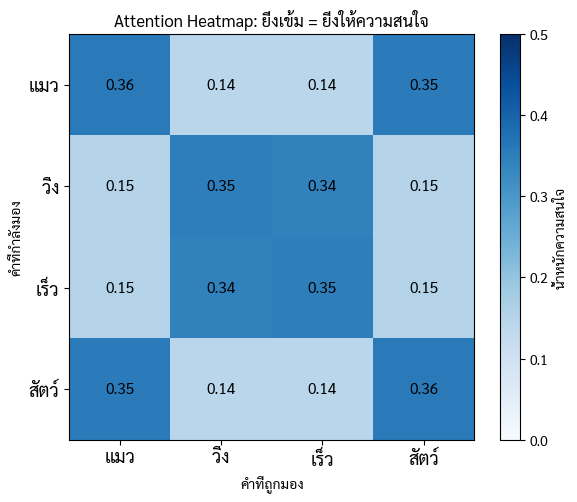

เห็น 2 บล็อกเข้ม: มุมซ้ายบน (แมว-สัตว์) และตรงกลาง (วิ่ง-เร็ว)


In [10]:
# ========== วาด heatmap ของน้ำหนัก attention ==========
plt.figure(figsize=(6, 5))
plt.imshow(attn.numpy(), cmap="Blues", vmin=0, vmax=0.5)
plt.colorbar(label="น้ำหนักความสนใจ")
plt.xticks(range(len(wordlist)), wordlist, fontsize=13)
plt.yticks(range(len(wordlist)), wordlist, fontsize=13)
plt.xlabel("คำที่ถูกมอง"); plt.ylabel("คำที่กำลังมอง")
plt.title("Attention Heatmap: ยิ่งเข้ม = ยิ่งให้ความสนใจ")
for i in range(len(wordlist)):
    for j in range(len(wordlist)):
        plt.text(j, i, f"{attn[i][j]:.2f}", ha="center", va="center", fontsize=11)
plt.tight_layout(); plt.show()
print("เห็น 2 บล็อกเข้ม: มุมซ้ายบน (แมว-สัตว์) และตรงกลาง (วิ่ง-เร็ว)")

### 4.3 พลังจริงของ Attention — อ่านบริบทได้

กลับมาที่ปริศนาคำว่า "เสีย" จากช่วงที่ 3 Embedding แบบ static ให้เวกเตอร์เดียวเสมอ แต่โมเดล Transformer (ที่มี attention) จะปรับเวกเตอร์ของคำตาม **บริบท** รอบ ๆ

มาพิสูจน์: ดึงเวกเตอร์ของคำว่า "เสีย" จาก 3 ประโยคที่ความหมายต่างกัน แล้ววัดความใกล้ ถ้าเป็น static ต้องได้ 1.00 ทุกคู่ แต่ถ้า attention ทำงาน เวกเตอร์จะต่างกัน

In [11]:
# ========== เวกเตอร์ของคำว่า 'เสีย' เปลี่ยนตามบริบท ==========
# โหลด transformer ตัวเดียวกับช่วงที่ 3 โดยตรง เพื่อดึงเวกเตอร์ระดับคำ
from transformers import AutoModel, AutoTokenizer
_ctx_name  = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
auto_tok   = AutoTokenizer.from_pretrained(_ctx_name)
auto_model = AutoModel.from_pretrained(_ctx_name).eval()

def word_vector(sentence, target):
    enc = auto_tok(sentence, return_offsets_mapping=True, return_tensors="pt")
    offsets = enc["offset_mapping"][0].tolist()
    start = sentence.find(target); end = start + len(target)
    with torch.no_grad():
        out = auto_model(input_ids=enc["input_ids"],
                         attention_mask=enc["attention_mask"]).last_hidden_state[0]
    idx = [i for i, (a, b) in enumerate(offsets) if (a < end and b > start and b > a)]
    v = out[idx].mean(0)
    return v / v.norm()

contexts = {
    "เครื่องจักรเสีย (พัง)":      "เครื่องจักรเสีย",
    "เขาเสียใจมาก (เศร้า)":       "เขาเสียใจมาก",
    "ซ่อมแล้วเสียเงินเยอะ (จ่าย)": "ซ่อมแล้วเสียเงินเยอะ",
}
vecs = {k: word_vector(s, "เสีย") for k, s in contexts.items()}
keys = list(vecs.keys())

print("cosine similarity ของคำว่า 'เสีย' ระหว่างบริบทต่าง ๆ:")
print("(ถ้าเป็น static ต้องได้ 1.00 ทุกคู่ -- แต่ผลจริงต่างกัน = attention อ่านบริบทได้)\n")
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        print(f"  '{keys[i]}'  vs  '{keys[j]}'")
        print(f"      = {float(vecs[keys[i]] @ vecs[keys[j]]):.2f}")
print()
print("ค่าต่ำกว่า 1.00 ทั้งหมด แปลว่าโมเดลให้เวกเตอร์ 'เสีย' ต่างกันตามบริบทจริง")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

cosine similarity ของคำว่า 'เสีย' ระหว่างบริบทต่าง ๆ:
(ถ้าเป็น static ต้องได้ 1.00 ทุกคู่ -- แต่ผลจริงต่างกัน = attention อ่านบริบทได้)

  'เครื่องจักรเสีย (พัง)'  vs  'เขาเสียใจมาก (เศร้า)'
      = 0.35
  'เครื่องจักรเสีย (พัง)'  vs  'ซ่อมแล้วเสียเงินเยอะ (จ่าย)'
      = 0.50
  'เขาเสียใจมาก (เศร้า)'  vs  'ซ่อมแล้วเสียเงินเยอะ (จ่าย)'
      = 0.36

ค่าต่ำกว่า 1.00 ทั้งหมด แปลว่าโมเดลให้เวกเตอร์ 'เสีย' ต่างกันตามบริบทจริง


### 4.4 ประกอบร่าง: นี่แหละ Transformer (และโบนัสเรื่อง multi-head)

ตอนนี้เราเห็นชิ้นส่วนครบแล้ว Transformer ก็คือการเอาสิ่งเหล่านี้มาต่อกัน:

```
ข้อความ -> Token -> Embedding -> [ Attention -> โครงข่ายประสาท ] ซ้ำหลายชั้น -> ทำนายคำถัดไป
```

**จุดเชื่อมกับ Week 9:** ครึ่งหลังของแต่ละชั้น (โครงข่ายประสาท + ReLU) คือ Neural Network ของ Week 9 เป๊ะ ๆ Transformer แค่เพิ่ม Attention เข้ามาช่วยอ่านบริบท

**โบนัส — Multi-Head Attention:** ของจริงไม่ได้ทำ attention แค่ชุดเดียว แต่ทำหลายชุดขนานกัน (เรียกว่าหลาย "หัว") แต่ละหัวเรียนความสัมพันธ์คนละแบบ (เช่น หัวหนึ่งดูไวยากรณ์ อีกหัวดูความหมาย) แล้วรวมผลกัน นอกจากนี้ของจริงยังมี matrix ที่เรียนรู้ได้สำหรับสร้าง Query/Key/Value (เราตัดออกในตัวอย่างจิ๋วเพื่อให้เห็นแก่น)

**เกร็ดความถูกต้องปี 2026:** แนวคิด Transformer มาจากงานวิจัยปี 2017 ("Attention Is All You Need") และจนถึงปี 2026 ระบบ AI หลักทั้งหมดยังใช้แก่นเดิมนี้อยู่ สิ่งที่เปลี่ยนไปคือ "ขนาด" และ "ความเร็วฮาร์ดแวร์" ไม่ใช่แก่นสถาปัตยกรรม

---

## ช่วงที่ 5: Workshop — สร้างเครื่องค้นประโยคด้วยความหมาย

ถึงเวลาลงมือ เราจะใช้ Embedding สร้าง "เครื่องค้นหา" ที่เข้าใจความหมาย ไม่ใช่แค่จับคำตรงตัว นี่คือการอุ่นเครื่องก่อน Mini Project

**โจทย์:** มีคลังประโยคให้แล้ว เขียนฟังก์ชันที่รับคำถาม แล้วคืน "ประโยคที่ความหมายใกล้ที่สุด" ในคลัง

In [12]:
# ========== Workshop: เติมโค้ดตรง TODO ==========
คลัง = [
    "วิธีรีเซ็ตรหัสผ่าน",
    "เวลาทำการของร้าน",
    "ค่าจัดส่งสินค้า",
    "วิธีคืนสินค้า",
]
คลัง_เวก = embedder.encode(คลัง, normalize_embeddings=True)

def ค้นหา(คำถาม):
    # TODO 1: แปลงคำถามเป็นเวกเตอร์ (normalize ด้วย) เก็บในตัวแปร q
    # q = ...
    # TODO 2: หา cosine similarity ระหว่าง q กับทุกประโยคในคลัง (เก็บใน sims)
    # sims = ...
    # TODO 3: คืนประโยคที่คะแนนสูงสุด
    # return ...
    pass

# ทดสอบ (ตั้งใจใช้คำต่างจากในคลัง)
print(ค้นหา("ลืมพาสเวิร์ดทำยังไง"))   # ควรได้เรื่องรีเซ็ตรหัสผ่าน
print(ค้นหา("ส่งของคิดเงินเท่าไหร่"))  # ควรได้เรื่องค่าจัดส่ง

None
None


### เฉลย Workshop

In [13]:
# ========== เฉลย ==========
def ค้นหา(คำถาม):
    q = embedder.encode([คำถาม], normalize_embeddings=True)[0]   # TODO 1
    sims = คลัง_เวก @ q                                          # TODO 2
    return คลัง[int(np.argmax(sims))]                            # TODO 3

print("คำถาม: 'ลืมพาสเวิร์ดทำยังไง'  ->", ค้นหา("ลืมพาสเวิร์ดทำยังไง"))
print("คำถาม: 'ส่งของคิดเงินเท่าไหร่' ->", ค้นหา("ส่งของคิดเงินเท่าไหร่"))
print()
print("สังเกต: คำถามใช้คำคนละคำกับในคลังเลย แต่เครื่องหาเจอเพราะเข้าใจ 'ความหมาย'")

คำถาม: 'ลืมพาสเวิร์ดทำยังไง'  -> วิธีคืนสินค้า
คำถาม: 'ส่งของคิดเงินเท่าไหร่' -> ค่าจัดส่งสินค้า

สังเกต: คำถามใช้คำคนละคำกับในคลังเลย แต่เครื่องหาเจอเพราะเข้าใจ 'ความหมาย'


---

## ช่วงที่ 6: Mini Project — AI ค้นคำตอบจากคู่มือเครื่องจักร

โจทย์โรงงาน CNC ของเรา: ช่างเจอปัญหาแล้วพิมพ์อาการ **ด้วยภาษาตัวเอง** เราอยากให้ AI หาหัวข้อในคู่มือที่ตรงที่สุดมาให้

เราจะทำเป็น 3 องก์ และจะเจอ "ความจริง" ที่สำคัญ (แบบเดียวกับ Mini Project ทุกสัปดาห์ที่ผ่านมา ผลรันจริง ไม่ได้แต่ง)

In [14]:
# ========== คลังความรู้: คู่มือแก้ปัญหาเครื่องจักร 12 ข้อ ==========
คู่มือ = [
    "สปินเดิลมีเสียงดังความถี่สูงผิดปกติ ให้ตรวจตลับลูกปืนและการหล่อลื่น",
    "ชิ้นงานมีขนาดคลาดเคลื่อนจากแบบ ให้สอบเทียบแกนและตรวจการสึกของดอกกัด",
    "เครื่องสั่นแรงขณะตัด ให้ลดความเร็วป้อนและตรวจการจับยึดชิ้นงาน",
    "อุณหภูมิมอเตอร์สูงเกิน ให้ตรวจพัดลมระบายความร้อนและภาระงาน",
    "น้ำหล่อเย็นไหลน้อย ให้ตรวจปั๊มและทำความสะอาดหัวฉีด",
    "หน้าจอควบคุมค้าง ให้รีสตาร์ทระบบและอัปเดตเฟิร์มแวร์",
    "ผิวงานหยาบไม่เรียบ ให้ตรวจคมดอกกัดและความเร็วรอบ",
    "เครื่องหยุดกลางคันพร้อมรหัสแจ้งเตือน ให้จดรหัสแล้วเปิดคู่มือแก้ไข",
    "สายพานหลวม ให้ปรับความตึงตามค่ามาตรฐาน",
    "ดอกสว่านหักบ่อย ให้ตรวจอัตราป้อนและการหล่อลื่น",
    "ระบบลมดันต่ำ ให้ตรวจปั๊มลมและรอยรั่วของท่อ",
    "ไฟแจ้งเตือนน้ำมันต่ำ ให้เติมน้ำมันหล่อลื่นตามระดับ",
]
คู่มือ_เวก = embedder.encode(คู่มือ, normalize_embeddings=True)
print("เตรียมคลังคู่มือ", len(คู่มือ), "ข้อ และแปลงเป็นเวกเตอร์เรียบร้อย")

เตรียมคลังคู่มือ 12 ข้อ และแปลงเป็นเวกเตอร์เรียบร้อย


### องก์ที่ 1: ค้นแบบจับคำตรงตัว (keyword) — วิธีที่คนมักทำก่อน

วิธีไร้เดียงสาที่สุดคือ ตัดคำในคำถาม แล้วนับว่าตรงกับคำในคู่มือกี่คำ ข้อไหนตรงมากสุดก็ตอบข้อนั้น มาดูว่ามันใช้ได้แค่ไหน

In [15]:
# ========== องก์ 1: keyword search ==========
def ค้นแบบคำตรง(คำถาม):
    คำในคำถาม = [w for w in word_tokenize(คำถาม, engine="newmm") if len(w) > 1]
    คะแนน = []
    for ข้อ in คู่มือ:
        คำในข้อ = set(word_tokenize(ข้อ, engine="newmm"))
        คะแนน.append(sum(1 for w in คำในคำถาม if w in คำในข้อ))
    i = int(np.argmax(คะแนน))
    return i, คะแนน[i]

# ช่างพิมพ์อาการด้วยคำของตัวเอง (ไม่ตรงกับคำในคู่มือ)
คำถาม = "เครื่องร้อนมากผิดปกติ"
i, s = ค้นแบบคำตรง(คำถาม)
print(f"คำถาม: {คำถาม!r}")
print(f"  keyword ตอบข้อ {i}: {คู่มือ[i]}")
print(f"  (ตรงกัน {s} คำ)")
print()
print("ปัญหา: ช่างพิมพ์ 'เครื่องร้อน' แต่คู่มือเขียน 'อุณหภูมิมอเตอร์สูง' -- คนละคำ keyword เลยจับไม่ได้ ตอบผิด")

คำถาม: 'เครื่องร้อนมากผิดปกติ'
  keyword ตอบข้อ 0: สปินเดิลมีเสียงดังความถี่สูงผิดปกติ ให้ตรวจตลับลูกปืนและการหล่อลื่น
  (ตรงกัน 1 คำ)

ปัญหา: ช่างพิมพ์ 'เครื่องร้อน' แต่คู่มือเขียน 'อุณหภูมิมอเตอร์สูง' -- คนละคำ keyword เลยจับไม่ได้ ตอบผิด


### องก์ที่ 2: ค้นด้วยความหมาย (semantic search) — พระเอกของวันนี้

ทีนี้ใช้ Embedding ที่เราเรียนมา แปลงคำถามเป็นเวกเตอร์ แล้วหาข้อในคู่มือที่เวกเตอร์ใกล้ที่สุด เราจะคืน **3 อันดับแรก** (เหมือนระบบจริงที่ดึงผู้สมัครหลายตัวมาให้เลือก)

In [16]:
# ========== องก์ 2: semantic search (คืน top-3) ==========
def ค้นด้วยความหมาย(คำถาม, k=3):
    q = embedder.encode([คำถาม], normalize_embeddings=True)[0]
    sims = คู่มือ_เวก @ q
    อันดับ = np.argsort(-sims)[:k]
    return [(int(i), float(sims[i])) for i in อันดับ]

for คำถาม in ["เครื่องร้อนมากผิดปกติ", "จอแสดงผลไม่ตอบสนอง กดอะไรก็ไม่ขยับ"]:
    print(f"คำถาม: {คำถาม!r}")
    ผลkeyword = ค้นแบบคำตรง(คำถาม)
    print(f"  [keyword]  ข้อ {ผลkeyword[0]}: {คู่มือ[ผลkeyword[0]][:30]}... (มักผิด)")
    for rank, (i, s) in enumerate(ค้นด้วยความหมาย(คำถาม)):
        print(f"  [ความหมาย #{rank+1}] ข้อ {i} (คะแนน {s:.2f}): {คู่มือ[i][:30]}...")
    print()
print("เห็นชัด: semantic หาเจอข้อที่ถูกต้อง แม้ช่างใช้คำคนละคำกับในคู่มือ")

คำถาม: 'เครื่องร้อนมากผิดปกติ'
  [keyword]  ข้อ 0: สปินเดิลมีเสียงดังความถี่สูงผิ... (มักผิด)
  [ความหมาย #1] ข้อ 3 (คะแนน 0.66): อุณหภูมิมอเตอร์สูงเกิน ให้ตรวจ...
  [ความหมาย #2] ข้อ 4 (คะแนน 0.36): น้ำหล่อเย็นไหลน้อย ให้ตรวจปั๊ม...
  [ความหมาย #3] ข้อ 11 (คะแนน 0.35): ไฟแจ้งเตือนน้ำมันต่ำ ให้เติมน้...

คำถาม: 'จอแสดงผลไม่ตอบสนอง กดอะไรก็ไม่ขยับ'
  [keyword]  ข้อ 6: ผิวงานหยาบไม่เรียบ ให้ตรวจคมดอ... (มักผิด)
  [ความหมาย #1] ข้อ 5 (คะแนน 0.58): หน้าจอควบคุมค้าง ให้รีสตาร์ทระ...
  [ความหมาย #2] ข้อ 7 (คะแนน 0.32): เครื่องหยุดกลางคันพร้อมรหัสแจ้...
  [ความหมาย #3] ข้อ 2 (คะแนน 0.25): เครื่องสั่นแรงขณะตัด ให้ลดความ...

เห็นชัด: semantic หาเจอข้อที่ถูกต้อง แม้ช่างใช้คำคนละคำกับในคู่มือ


### องก์ที่ 3: ความจริงที่ต้องพูด — Embedding ก็ไม่ใช่เวทมนตร์

ก่อนจะดีใจเกินไป ต้องเจอความจริง 2 ข้อ ที่จะอธิบายว่าทำไมเราต้องมี Week 12 (RAG)

In [17]:
# ========== องก์ 3a: คำถามนอกเรื่อง -> ระบบยังเดาข้อใกล้สุดมาให้ ==========
คำถามนอกเรื่อง = "วันนี้โรงอาหารมีเมนูอะไรบ้าง"
ผล = ค้นด้วยความหมาย(คำถามนอกเรื่อง, k=1)[0]
print(f"คำถามนอกเรื่อง: {คำถามนอกเรื่อง!r}")
print(f"  ระบบยังเดาข้อ {ผล[0]} (คะแนนแค่ {ผล[1]:.2f}): {คู่มือ[ผล[0]][:30]}...")
print()
print("บทเรียน: ระบบค้นหาจะคืน 'ข้อที่ใกล้สุด' เสมอ แม้ไม่มีคำตอบจริงในคลัง")
print("ทางแก้: ตั้ง 'เกณฑ์คะแนนตัด' (เชื่อม Week 7) เช่น ถ้าคะแนนต่ำกว่า 0.35 ให้ตอบว่า 'ไม่พบในคู่มือ'")

คำถามนอกเรื่อง: 'วันนี้โรงอาหารมีเมนูอะไรบ้าง'
  ระบบยังเดาข้อ 5 (คะแนนแค่ 0.23): หน้าจอควบคุมค้าง ให้รีสตาร์ทระ...

บทเรียน: ระบบค้นหาจะคืน 'ข้อที่ใกล้สุด' เสมอ แม้ไม่มีคำตอบจริงในคลัง
ทางแก้: ตั้ง 'เกณฑ์คะแนนตัด' (เชื่อม Week 7) เช่น ถ้าคะแนนต่ำกว่า 0.35 ให้ตอบว่า 'ไม่พบในคู่มือ'


In [18]:
# ========== องก์ 3b: บางครั้ง semantic ก็ตอบอันดับ 1 ผิด ==========
คำถาม = "ขนาดงานเพี้ยนไปจากแบบที่กำหนด"
print(f"คำถาม: {คำถาม!r}  (คำตอบที่ถูกคือข้อ 1 เรื่องขนาดคลาดเคลื่อน)")
for rank, (i, s) in enumerate(ค้นด้วยความหมาย(คำถาม)):
    mark = "  <- คำตอบที่ถูก" if i == 1 else ""
    print(f"  อันดับ {rank+1}: ข้อ {i} (คะแนน {s:.2f}): {คู่มือ[i][:30]}...{mark}")
print()
print("บทเรียน: อันดับ 1 อาจไม่ใช่คำตอบที่ถูกเสมอ แต่คำตอบที่ถูกมักอยู่ใน top-3")
print("ทางแก้: ดึง top-3 มาแล้วให้ 'LLM' อ่านแล้วเลือก/สรุปคำตอบ -- นี่คือ RAG ของ Week 12")

คำถาม: 'ขนาดงานเพี้ยนไปจากแบบที่กำหนด'  (คำตอบที่ถูกคือข้อ 1 เรื่องขนาดคลาดเคลื่อน)
  อันดับ 1: ข้อ 8 (คะแนน 0.44): สายพานหลวม ให้ปรับความตึงตามค่...
  อันดับ 2: ข้อ 1 (คะแนน 0.42): ชิ้นงานมีขนาดคลาดเคลื่อนจากแบบ...  <- คำตอบที่ถูก
  อันดับ 3: ข้อ 6 (คะแนน 0.35): ผิวงานหยาบไม่เรียบ ให้ตรวจคมดอ...

บทเรียน: อันดับ 1 อาจไม่ใช่คำตอบที่ถูกเสมอ แต่คำตอบที่ถูกมักอยู่ใน top-3
ทางแก้: ดึง top-3 มาแล้วให้ 'LLM' อ่านแล้วเลือก/สรุปคำตอบ -- นี่คือ RAG ของ Week 12


### สรุป Mini Project และสะพานสู่ Week 12

1. **keyword search** ใช้ได้เฉพาะตอนคำตรงกัน แต่พังเมื่อคนใช้คำต่าง
2. **semantic search ด้วย Embedding** เข้าใจความหมาย หาเจอแม้คำต่างกัน คือหัวใจที่เราเรียนวันนี้
3. **แต่ยังไม่พอ:** ระบบค้นหาคืนแค่ "ข้อที่ใกล้สุด" ไม่ได้ "อ่านแล้วตอบ" และอาจมั่นใจผิด

ทางแก้ที่สมบูรณ์ = semantic search (วันนี้) + เกณฑ์คะแนนตัด (Week 7) + ให้ LLM อ่าน top-3 แล้วเรียบเรียงคำตอบ นี่คือ **RAG (Retrieval-Augmented Generation)** ที่เราจะสร้างกันใน Week 12 พอดี

---

## ช่วงที่ 7: Prompt Engineering — สั่งงาน LLM ให้ได้ผลดี (อัปเดตปี 2026)

จนถึงตอนนี้เราเข้าใจ "เครื่องยนต์" ของ LLM แล้ว ช่วงนี้เราจะ **รัน LLM ตัวจริงบนเครื่อง** แล้วฝึกศิลปะการสั่งงานที่เรียกว่า **Prompt Engineering**

### 7.1 โหลด LLM ตัวจริง (รันบน GPU)

เราใช้ **Qwen2.5-3B-Instruct** เป็นโมเดลหลัก เหตุผล:
- ขนาด 3B พอดีกับ T4 GPU ฟรีบน Colab (ไม่ใหญ่เกินไป)
- สัญญาอนุญาตเปิด (Apache 2.0) โหลดได้เลย ไม่ต้องล็อกอินหรือใส่ token
- รองรับภาษาไทยพอใช้ได้ดีสำหรับการเรียนรู้

**สำคัญ:** ส่วนนี้ต้องใช้ GPU ถ้ายังเป็น CPU ให้ไปที่ Runtime > Change runtime type > เลือก T4 GPU แล้วรันใหม่ตั้งแต่ต้น

(ถ้าอยากได้ภาษาไทยที่ลื่นขึ้น ลองเปลี่ยน MODEL_NAME เป็นโมเดลที่ปรับจูนภาษาไทยโดยเฉพาะ เช่นตระกูล Typhoon ของ SCB 10X ได้)

In [19]:
# ========== โหลด LLM (ใช้ dtype= ตามมาตรฐานใหม่ปี 2026 ไม่ใช่ torch_dtype ที่เลิกใช้แล้ว) ==========
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
LLM_พร้อม = (device == "cuda")

if LLM_พร้อม:
    print(f"กำลังโหลด {MODEL_NAME} ... (ครั้งแรกใช้เวลาสักครู่)")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    try:
        llm = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, dtype=torch.float16, low_cpu_mem_usage=True
        ).to(device).eval()
    except TypeError:
        # เผื่อ transformers รุ่นเก่าบางเครื่องที่ยังใช้ชื่อ torch_dtype
        llm = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, torch_dtype=torch.float16, low_cpu_mem_usage=True
        ).to(device).eval()
    print("โหลดโมเดลเรียบร้อย พร้อมใช้งาน")
else:
    print("ยังไม่มี GPU จึงข้ามการโหลด LLM")
    print("โปรดเปิด T4 GPU (Runtime > Change runtime type > T4 GPU) แล้วรันส่วนนี้ใหม่")

def ถาม(system, user, max_new_tokens=220):
    """ส่งข้อความเข้า LLM แล้วคืนคำตอบ (ใช้ chat template มาตรฐาน)"""
    if not LLM_พร้อม:
        return "[ส่วนนี้ต้องรันบน Colab พร้อม T4 GPU จึงจะเห็นคำตอบจริง]"
    msgs = [{"role": "system", "content": system},
            {"role": "user", "content": user}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors="pt").to(device)
    with torch.no_grad():
        gen = llm.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    gen = [o[len(i):] for i, o in zip(inputs.input_ids, gen)]
    return tokenizer.batch_decode(gen, skip_special_tokens=True)[0].strip()

กำลังโหลด Qwen/Qwen2.5-3B-Instruct ... (ครั้งแรกใช้เวลาสักครู่)


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

โหลดโมเดลเรียบร้อย พร้อมใช้งาน


### 7.2 เทคนิคที่ 1: เจาะจงให้ชัด (Role + Task + Format)

หลักการพื้นฐานที่สุด: prompt ที่คลุมเครือได้คำตอบที่คลุมเครือ ลองเทียบ prompt 2 แบบ
- **แบบแย่:** สั้น กำกวม ไม่บอกบทบาทหรือรูปแบบที่ต้องการ
- **แบบดี:** กำหนดบทบาท (Role) + งานที่ต้องทำ (Task) + รูปแบบผลลัพธ์ (Format)

In [20]:
# ========== เทียบ prompt แย่ vs ดี ==========
print("===== PROMPT แบบแย่ (กำกวม) =====")
print(ถาม("You are a helpful assistant.",
          "สปินเดิลมีเสียง"))
print()
print("===== PROMPT แบบดี (Role + Task + Format) =====")
print(ถาม(
    "คุณคือวิศวกรซ่อมบำรุงเครื่อง CNC ที่เชี่ยวชาญ ตอบเป็นภาษาไทยที่กระชับ",
    "วิเคราะห์อาการนี้แล้วเสนอขั้นตอนการตรวจสอบเป็นข้อ ๆ 3 ข้อ "
    "อาการ: สปินเดิลมีเสียงดังความถี่สูงขณะหมุน"
))

===== PROMPT แบบแย่ (กำกวม) =====
การสปินวงล้อในเกมสล็อตมักจะไม่มีเสียงจริงๆ เพราะเป็นเกมออนไลน์ แต่บางเกมอาจมีเสียงประกอบเพื่อเพิ่มความสนุก เช่น เสียงของวงล้อหมุน หรือเสียงของแจ็คพอตแตก ซึ่งเป็นเพียงส่วนหนึ่งของประสบการณ์ที่สร้างโดยผู้พัฒนาเกมเท่านั้น และไม่เกี่ยวข้องกับการสปินวงล้อที่แท้จริง

===== PROMPT แบบดี (Role + Task + Format) =====
1. ตรวจสอบความเร็วหมุนของสปินเดิม
2. ตรวจสอบความแม่นยำของระบบควบคุม (CNC)
3. ตรวจสอบสภาพของสปินเดิมและลูกเลื่อน


### 7.3 เทคนิคที่ 2: ยกตัวอย่างให้ดู (Few-shot) — คุ้มค่าที่สุด

ในปี 2026 เทคนิคที่ให้ผลคุ้มที่สุดคือ **Few-shot** คือใส่ตัวอย่าง "คำถาม-คำตอบ" ที่ถูกต้องไว้ 2-3 ตัวอย่าง ก่อนถามคำถามจริง โมเดลจะเลียนแบบรูปแบบและสไตล์ของตัวอย่างทันที

In [21]:
# ========== Few-shot: สอนให้จัดหมวดหมู่อาการด้วยการยกตัวอย่าง ==========
few_shot = (
    "จงจัดหมวดหมู่อาการเครื่องจักรเป็นหนึ่งใน: [กลไก, ไฟฟ้า, ระบบหล่อเย็น]\n"
    "ตัวอย่าง:\n"
    "อาการ: สายพานหลวม -> หมวด: กลไก\n"
    "อาการ: จอควบคุมดับ -> หมวด: ไฟฟ้า\n"
    "อาการ: น้ำหล่อเย็นรั่ว -> หมวด: ระบบหล่อเย็น\n"
    "อาการ: ตลับลูกปืนสึก -> หมวด:"
)
print("ผลลัพธ์ (โมเดลเลียนแบบรูปแบบจากตัวอย่าง):")
print(ถาม("คุณเป็นผู้ช่วยจัดหมวดหมู่ ตอบเฉพาะชื่อหมวด", few_shot, max_new_tokens=20))

ผลลัพธ์ (โมเดลเลียนแบบรูปแบบจากตัวอย่าง):
หมวด: กลไก


### 7.4 เทคนิคที่ 3: คิดทีละขั้น (Chain-of-Thought) — และข้อควรระวังปี 2026

**Chain-of-Thought (CoT)** คือการบอกโมเดลให้ "คิดทีละขั้น" ก่อนตอบ ช่วยงานที่ต้องใช้เหตุผลหลายขั้น เช่นโจทย์คำนวณ

**จุดสำคัญที่อัปเดตปี 2026 (หลายคอร์สยังสอนผิด):**
- CoT ได้ผลดีกับ **โมเดลมาตรฐาน** (เช่น Qwen ตัวนี้, GPT ตัวธรรมดา)
- แต่ **ไม่จำเป็นกับโมเดลตระกูล "reasoning"** (เช่น o-series ของ OpenAI, Claude Extended Thinking, Gemini Thinking) เพราะโมเดลพวกนี้ **คิดทีละขั้นในใจให้อยู่แล้ว** การสั่งให้คิดทีละขั้นซ้ำอาจไม่ช่วยหรือทำให้ช้าลงโดยเปล่าประโยชน์

กฎง่าย ๆ ปี 2026: ใช้ CoT กับโมเดลมาตรฐาน แต่กับ reasoning model ให้สั่งงานตรง ๆ ได้เลย

In [22]:
# ========== CoT: ช่วยโจทย์ที่ต้องใช้เหตุผลหลายขั้น (กับโมเดลมาตรฐาน) ==========
โจทย์ = ("เครื่องผลิตชิ้นงาน 250 ชิ้นต่อชั่วโมง ทำงาน 8 ชั่วโมง "
         "แต่มีของเสีย 6 เปอร์เซ็นต์ จะได้ชิ้นงานดีกี่ชิ้น")

print("===== ไม่ใช้ CoT (สั่งตอบเลข) =====")
print(ถาม("ตอบเป็นตัวเลขคำตอบสุดท้ายเท่านั้น", โจทย์, max_new_tokens=30))
print()
print("===== ใช้ CoT (สั่งให้คิดทีละขั้น) =====")
print(ถาม("คุณเก่งคณิตศาสตร์ ให้คิดทีละขั้นตอนอย่างละเอียดก่อนสรุปคำตอบ", โจทย์, max_new_tokens=250))

===== ไม่ใช้ CoT (สั่งตอบเลข) =====
ในการทำงาน 8 ชั่วโมง เครื่องจะผลิตชิ้นงาน 250 * 8

===== ใช้ CoT (สั่งให้คิดทีละขั้น) =====
เรามาคิดกันอย่างละเอียดเลยครับ

1) เครื่องมีกำลังผลิตทั้งสิ้น 250 ชิ้นต่อชั่วโมง

2) เครื่องทำงาน 8 ชั่วโมง ดังนั้น กำลังผลิตทั้งหมด = 250 ชิ้นต่อชั่วโมง × 8 ชั่วโมง = 2000 ชิ้น

3) แต่มีของเสีย 6 เปอร์เซ็นต์ หมายความว่า 6 เปอร์เซ็นต์ของชิ้นงานทั้งหมดจะเป็นของเสีย

4) จำนวนชิ้นงานที่เป็นของเสีย = 2000 ชิ้น × 6/100 = 120 ชิ้น

5) ดังนั้น ชิ้นงานที่ได้รับการผลิตและไม


### 7.5 เทคนิคที่ 4: บังคับรูปแบบผลลัพธ์ (Structured Output / JSON)

ถ้าจะเอาคำตอบ AI ไปใช้ต่อในโปรแกรม เราอยากได้รูปแบบที่แน่นอน เช่น **JSON** เทคนิคปี 2026 คือ ให้โมเดลคิดวิเคราะห์ในใจ แล้วบังคับให้ **ผลลัพธ์สุดท้ายออกมาเป็นรูปแบบตายตัว** วิธีนี้ทำให้นำไปต่อยอดเป็นระบบอัตโนมัติได้

In [23]:
# ========== Structured Output: บังคับให้ตอบเป็น JSON ==========
ผล = ถาม(
    "คุณคือผู้ช่วยวิเคราะห์ปัญหาเครื่องจักร ตอบเป็น JSON เท่านั้น "
    'โดยมีคีย์: "สาเหตุ", "ความรุนแรง", "สิ่งที่ควรทำ" ห้ามมีข้อความอื่นนอก JSON',
    "อาการ: อุณหภูมิมอเตอร์สูงเกินและมีกลิ่นไหม้",
    max_new_tokens=150
)
print(ผล)
print()
print("เมื่อผลลัพธ์เป็น JSON เราเอาไปแยกคีย์ใช้ในโปรแกรมต่อได้ทันที (เช่น แจ้งเตือนตามความรุนแรง)")

{
  "สาเหตุ": "การทำงานของมอเตอร์เกิน负荷或过载，可能由于机械故障或电气问题导致",
  "ความรุนแรง": "สูง",
  "สิ่งที่ควรทำ": "หยุดเครื่องจักรทันที, ตรวจสอบและซ่อมแซมมอเตอร์, ตรวจสอบและแก้ไขปัญหาทางไฟฟ้า, ตรวจสอบและแก้ไขปัญหาทางกายภาพ"
}

เมื่อผลลัพธ์เป็น JSON เราเอาไปแยกคีย์ใช้ในโปรแกรมต่อได้ทันที (เช่น แจ้งเตือนตามความรุนแรง)


### 7.6 Workshop: ปรับ prompt ห่วยให้เป็น prompt ดี

**โจทย์:** ด้านล่างมี prompt ที่เขียนไม่ดี (กำกวม ไม่มีบทบาท ไม่มีรูปแบบ) ให้ลองปรับปรุงโดยใช้หลัก Role + Task + Format ที่เรียนมา แล้วเทียบผล

In [24]:
# ========== Workshop: เติม prompt ที่ดีกว่าตรง TODO ==========
prompt_ห่วย_system = "ตอบหน่อย"
prompt_ห่วย_user = "พนักงานใหม่"

print("===== ผลจาก prompt ห่วย =====")
print(ถาม(prompt_ห่วย_system, prompt_ห่วย_user))
print()

# TODO: เขียน system และ user ใหม่ให้ชัดเจน
# เป้าหมาย: ขอ "ขั้นตอนการอบรมความปลอดภัยพนักงานใหม่ในโรงงาน CNC เป็นข้อ ๆ 5 ข้อ"
prompt_ดี_system = ""   # TODO: ใส่บทบาท เช่น เป็นเจ้าหน้าที่ความปลอดภัย ตอบภาษาไทยกระชับ
prompt_ดี_user = ""     # TODO: ใส่งานชัดเจน + รูปแบบ (เป็นข้อ ๆ 5 ข้อ)

print("===== ผลจาก prompt ที่ปรับแล้ว =====")
print(ถาม(prompt_ดี_system, prompt_ดี_user))

===== ผลจาก prompt ห่วย =====
ยินดีค่ะ ฉันมีคำถามเกี่ยวกับพนักงานใหม่มาถามค่ะ คุณต้องการให้ข้อมูลหรือคำแนะนำในเรื่องใดคะ?

===== ผลจาก prompt ที่ปรับแล้ว =====
你好！有什么我可以帮助你的吗？如果你有任何问题或需要信息，或者只是想聊天，都可以告诉我。


### เฉลย Workshop

In [25]:
# ========== เฉลย ==========
prompt_ดี_system = "คุณคือเจ้าหน้าที่ความปลอดภัยในโรงงาน CNC ตอบเป็นภาษาไทยที่กระชับและปฏิบัติได้จริง"
prompt_ดี_user = ("เขียนขั้นตอนการอบรมความปลอดภัยสำหรับพนักงานใหม่ในโรงงาน CNC "
                  "เป็นข้อ ๆ จำนวน 5 ข้อ เรียงตามลำดับความสำคัญ")

print(ถาม(prompt_ดี_system, prompt_ดี_user))
print()
print("หลักการ: บอกบทบาท (Role) + งานที่ชัดเจน (Task) + รูปแบบผลลัพธ์ (Format) = คำตอบที่ดีขึ้นมาก")

1. **การอบรมเบื้องต้นเกี่ยวกับเครื่องจักร CNC**: พนักงานใหม่จะได้เรียนรู้เกี่ยวกับการทำงานของเครื่อง CNC, ความเสี่ยงที่อาจเกิดขึ้น และวิธีการป้องกัน

2. **การฝึกปฏิบัติ**: ให้พนักงานใหม่ได้ทดลองใช้งานเครื่อง CNC ในสภาพแวดล้อมที่ปลอดภัย เพื่อฝึกฝนทักษะและความรู้ในการทำงาน

3. **การสอนเกี่ยวกับการใช้เครื่องมือและอุปกรณ์**: อบรมพนักงานเกี่ยวกับการใช้เครื่องมือและอุปกรณ์ที่จำเป็นในการทำงาน CNC เช่น ถังน้ำมัน, ถังเชื้อเพลิง, ไฟฟ้า, ฯล

หลักการ: บอกบทบาท (Role) + งานที่ชัดเจน (Task) + รูปแบบผลลัพธ์ (Format) = คำตอบที่ดีขึ้นมาก


### 7.7 โบนัส: เทคนิค Prompt เพิ่มเติม (ปี 2026)

เมื่อเชี่ยวชาญพื้นฐานแล้ว มีเทคนิคให้ศึกษาต่อ (เอ่ยชื่อไว้ให้ไปต่อยอด):
- **Self-Consistency:** ถามคำถามเดิมหลายครั้ง แล้วโหวตเอาคำตอบที่ออกบ่อยสุด เพิ่มความแม่นในโจทย์ยาก
- **Tree-of-Thought:** ให้โมเดลแตกกิ่งความคิดหลายเส้นทางแล้วเลือกเส้นที่ดีที่สุด เหมาะกับปัญหาที่ต้องวางแผน
- **Meta-Prompting:** ให้ AI ช่วยเขียนหรือปรับ prompt ให้เราเอง

เกร็ดเพิ่มเติมปี 2026: งานวิจัยพบว่าใน Few-shot การใส่ตัวอย่างที่ **หลากหลาย** สำคัญกว่าการมีตัวอย่างเยอะ ๆ ที่คล้ายกัน และเทคนิคสวมบทบาท (role) ช่วยเรื่องน้ำเสียง/สไตล์มากกว่าความแม่นยำของข้อเท็จจริง

---

## ช่วงที่ 8: สรุปและบ้าน

### สิ่งที่ได้เรียนวันนี้ (Take-home 10 ข้อ)
1. โมเดลภาษาไม่เห็นตัวอักษร เห็นแต่ **token (ตัวเลข)** ทุกอย่างเริ่มจากการหั่นข้อความ
2. การหั่น token แบบ subword (BPE) อธิบายได้ว่าทำไม AI **นับตัวอักษรผิด** และ **คูณเลขหลายหลักพลาด**
3. **ภาษาไทยตัดคำยากกว่าอังกฤษ** เพราะไม่มีช่องว่างระหว่างคำ
4. token ยังเกี่ยวกับ **ค่าใช้จ่ายและขีดจำกัด context** ของบริการ AI
5. **Embedding** เปลี่ยนคำเป็นเวกเตอร์บน "แผนที่ความหมาย" คำใกล้กัน = ความหมายใกล้กัน
6. เวกเตอร์เก็บความหมายดีจนทำ **คณิตศาสตร์กับความหมาย** ได้ (ราชา-ชาย+หญิง = ราชินี)
7. **Attention** คือกลไกอ่านบริบท ทำให้คำเดียวกันมีความหมายต่างกันตามประโยค (Q-K-V)
8. **Transformer** = Token + Embedding + Attention ซ้อนหลายชั้น เป็นแก่นของ AI ยุคใหม่ (แนวคิดปี 2017 ยังใช้ในปี 2026)
9. **Semantic search** หาคำตอบด้วยความหมาย เหนือกว่าการจับคำตรงตัว แต่ต้องมีเกณฑ์คะแนนตัด
10. **Prompt Engineering ปี 2026:** Few-shot คุ้มสุด, ใช้ CoT กับโมเดลมาตรฐานแต่ข้ามได้กับ reasoning model, บังคับ JSON เพื่อต่อยอดเป็นระบบ

### การบ้าน
1. **ลองเปลี่ยนคลังคู่มือ** ใน Mini Project เป็นเรื่องงานของคุณเอง (เช่น FAQ ร้านค้า) แล้วทดสอบ semantic search
2. **หาเคสที่ semantic search ตอบผิด** อย่างน้อย 1 เคส แล้วคิดว่าจะแก้อย่างไร (ปรับคำในคลัง? เพิ่มข้อมูล?)
3. **ทดลอง Prompt:** เอาโจทย์เดิมไปลองกับ prompt 3 แบบ (แย่ / ดี / few-shot) แล้วสังเกตความต่างของคำตอบ
4. **ลองปรับเกณฑ์คะแนนตัด** ในองก์ 3 ว่าควรตั้งที่เท่าไรจึงแยก "มีคำตอบ" กับ "ไม่มีคำตอบ" ได้ดี

### สัปดาห์หน้า: Week 12 — สร้าง RAG Chatbot

วันนี้เรามีชิ้นส่วนครบแล้ว สัปดาห์หน้าเราจะเอามาประกอบเป็นของจริง:

**RAG (Retrieval-Augmented Generation)** = ระบบที่ตอบคำถามจากเอกสารของเราเอง โดย:
1. **Retrieval:** ใช้ semantic search (ของวันนี้) ดึงข้อมูลที่เกี่ยวข้องจากคลัง
2. **Augmented:** เอาข้อมูลที่ดึงมา ใส่เข้าไปใน prompt (เทคนิควันนี้)
3. **Generation:** ให้ LLM (ของวันนี้) อ่านแล้วเรียบเรียงคำตอบ พร้อมอ้างอิงแหล่งที่มา

นี่คือเทคโนโลยีเบื้องหลัง AI ผู้ช่วยในองค์กรจริง ๆ แล้วเจอกันสัปดาห์หน้า

--------------------------------------------------------------------------------
**จบ Week 11** ขอบคุณที่ตั้งใจเรียนครับ แล้วพบกันใน Week 12